In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/ieee-fraud-detection/sample_submission.csv
/kaggle/input/competitions/ieee-fraud-detection/test_identity.csv
/kaggle/input/competitions/ieee-fraud-detection/train_identity.csv
/kaggle/input/competitions/ieee-fraud-detection/test_transaction.csv
/kaggle/input/competitions/ieee-fraud-detection/train_transaction.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

train_txn = pd.read_csv('/kaggle/input/competitions/ieee-fraud-detection/train_transaction.csv')
train_id = pd.read_csv('/kaggle/input/competitions/ieee-fraud-detection/train_identity.csv')

print(f"Transaction shape : {train_txn.shape}")
print(f"Identity shape : {train_id.shape}")

Transaction shape : (590540, 394)
Identity shape : (144233, 41)


In [3]:
fraud_counts = train_txn['isFraud'].value_counts()
frauc_pct = train_txn['isFraud'].mean()*100
print(f"Fraud : {fraud_counts[1]} ({frauc_pct:.4f}%)")
print(f"Not Fraud : {fraud_counts[0]} ({100 - frauc_pct:.4f}%)")

Fraud : 20663 (3.4990%)
Not Fraud : 569877 (96.5010%)


In [4]:
print(f"TransactionDT range: {train_txn['TransactionDT'].min()} to {train_txn['TransactionDT'].max()}")
print(f"That's roughly {(train_txn['TransactionDT'].max() - train_txn['TransactionDT'].min()) / 86400:.0f} days of data")

TransactionDT range: 86400 to 15811131
That's roughly 182 days of data


In [5]:
# Calculate missing percentage for every column
missing = train_txn.isnull().mean().sort_values(ascending=False) * 100

# Show columns with most missing values
print("Top 20 columns by missing %:\n")
print(missing.head(20).to_string())

print(f"\n\nColumns with >50% missing: {(missing > 50).sum()}")
print(f"Columns with 0% missing: {(missing == 0).sum()}")

Top 20 columns by missing %:

dist2    93.628374
D7       93.409930
D13      89.509263
D14      89.469469
D12      89.041047
D6       87.606767
D9       87.312290
D8       87.312290
V153     86.123717
V149     86.123717
V141     86.123717
V146     86.123717
V154     86.123717
V162     86.123717
V142     86.123717
V158     86.123717
V161     86.123717
V157     86.123717
V138     86.123717
V139     86.123717


Columns with >50% missing: 174
Columns with 0% missing: 20


In [6]:
# Get missing percentages for V columns only
v_cols = [c for c in train_txn.columns if c.startswith('V')]
v_missing = train_txn[v_cols].isnull().mean() * 100

# Group V columns by their missing percentage
v_groups = v_missing.round(2).reset_index()
v_groups.columns = ['feature', 'missing_pct']
v_groups_summary = v_groups.groupby('missing_pct')['feature'].apply(list)

for pct, cols in v_groups_summary.items():
    print(f"\n{pct}% missing ({len(cols)} columns):")
    print(f"  {cols[0]} ... {cols[-1]}")


0.0% missing (32 columns):
  V279 ... V321

0.05% missing (43 columns):
  V95 ... V137

0.21% missing (11 columns):
  V281 ... V315

12.88% missing (23 columns):
  V12 ... V34

13.06% missing (22 columns):
  V53 ... V74

15.1% missing (20 columns):
  V75 ... V94

28.61% missing (18 columns):
  V35 ... V52

47.29% missing (11 columns):
  V1 ... V11

76.05% missing (16 columns):
  V220 ... V272

76.32% missing (19 columns):
  V169 ... V210

76.36% missing (31 columns):
  V167 ... V216

77.91% missing (46 columns):
  V217 ... V278

86.05% missing (18 columns):
  V322 ... V339

86.12% missing (29 columns):
  V138 ... V166


In [7]:
# Columns with no missing values
no_missing = missing[missing == 0].index.tolist()
print(f"Columns with no missing values ({len(no_missing)}):\n{no_missing}")

Columns with no missing values (20):
['C1', 'C3', 'C2', 'card1', 'C4', 'C11', 'C12', 'C6', 'C7', 'C8', 'C9', 'C10', 'C5', 'C13', 'C14', 'ProductCD', 'TransactionAmt', 'TransactionDT', 'isFraud', 'TransactionID']


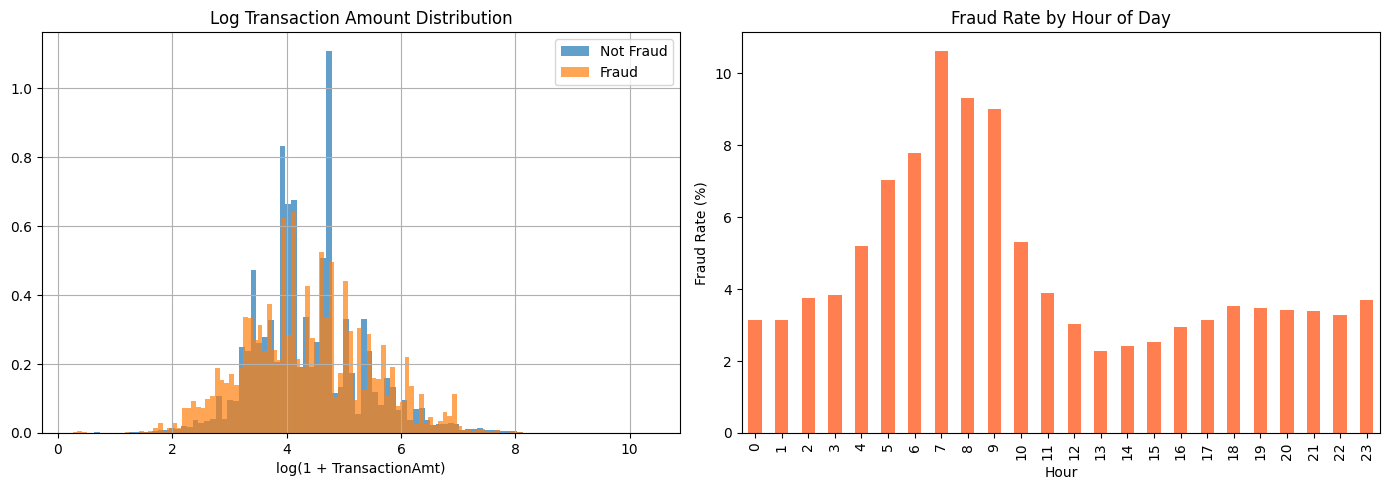

In [8]:
# Transaction amount distribution: fraud vs non-fraud
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

train_txn[train_txn['isFraud'] == 0]['TransactionAmt'].apply(np.log1p).hist(
    bins=100, ax=axes[0], alpha=0.7, label='Not Fraud', density=True)
train_txn[train_txn['isFraud'] == 1]['TransactionAmt'].apply(np.log1p).hist(
    bins=100, ax=axes[0], alpha=0.7, label='Fraud', density=True)
axes[0].set_title('Log Transaction Amount Distribution')
axes[0].set_xlabel('log(1 + TransactionAmt)')
axes[0].legend()

train_txn['hour'] = (train_txn['TransactionDT'] / 3600) % 24
hourly_fraud = train_txn.groupby(train_txn['hour'].astype(int))['isFraud'].mean() * 100
hourly_fraud.plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('Fraud Rate by Hour of Day')
axes[1].set_ylabel('Fraud Rate (%)')
axes[1].set_xlabel('Hour')

plt.tight_layout()
plt.show()

train_txn.drop('hour', axis=1, inplace=True)

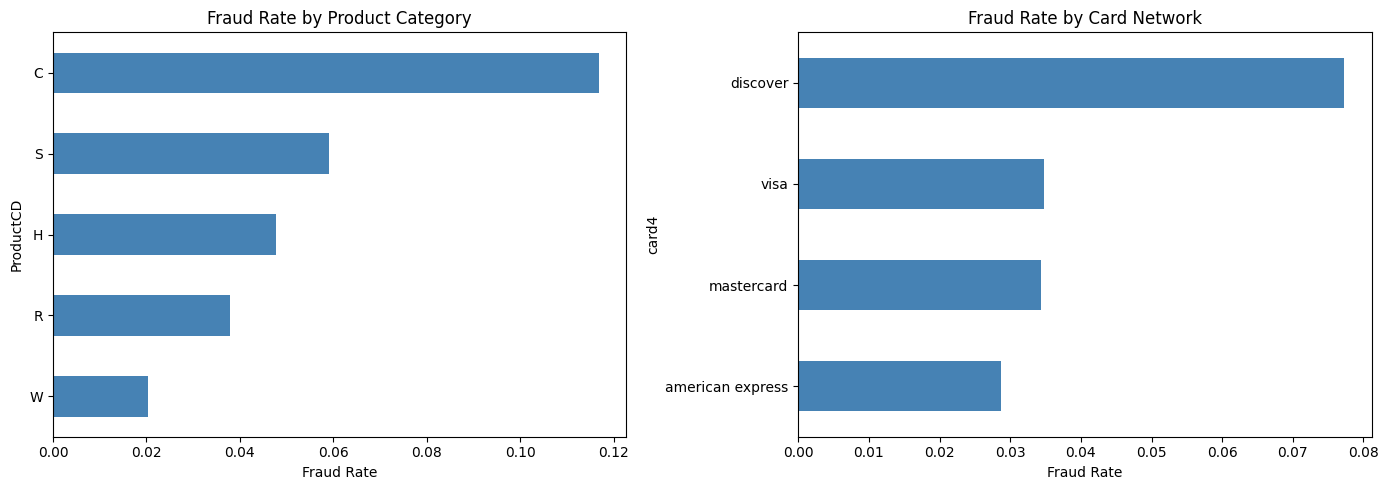

In [9]:
# Fraud rate by ProductCD and card4 (card network)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

train_txn.groupby('ProductCD')['isFraud'].mean().sort_values().plot(
    kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Fraud Rate by Product Category')
axes[0].set_xlabel('Fraud Rate')

train_txn.groupby('card4')['isFraud'].mean().sort_values().plot(
    kind='barh', ax=axes[1], color='steelblue')
axes[1].set_title('Fraud Rate by Card Network')
axes[1].set_xlabel('Fraud Rate')

plt.tight_layout()
plt.show()

In [10]:
# Merge transaction and identity tables
train = train_txn.merge(train_id, on='TransactionID', how='left')
print(f"Merged shape: {train.shape}")

# Check: does having identity info correlate with fraud?
train['has_identity'] = train_id_cols = (~train['DeviceType'].isnull()).astype(int)
print(f"\nFraud rate WITH identity info: {train[train['has_identity']==1]['isFraud'].mean()*100:.2f}%")
print(f"Fraud rate WITHOUT identity info: {train[train['has_identity']==0]['isFraud'].mean()*100:.2f}%")

Merged shape: (590540, 434)

Fraud rate WITH identity info: 7.96%
Fraud rate WITHOUT identity info: 2.10%


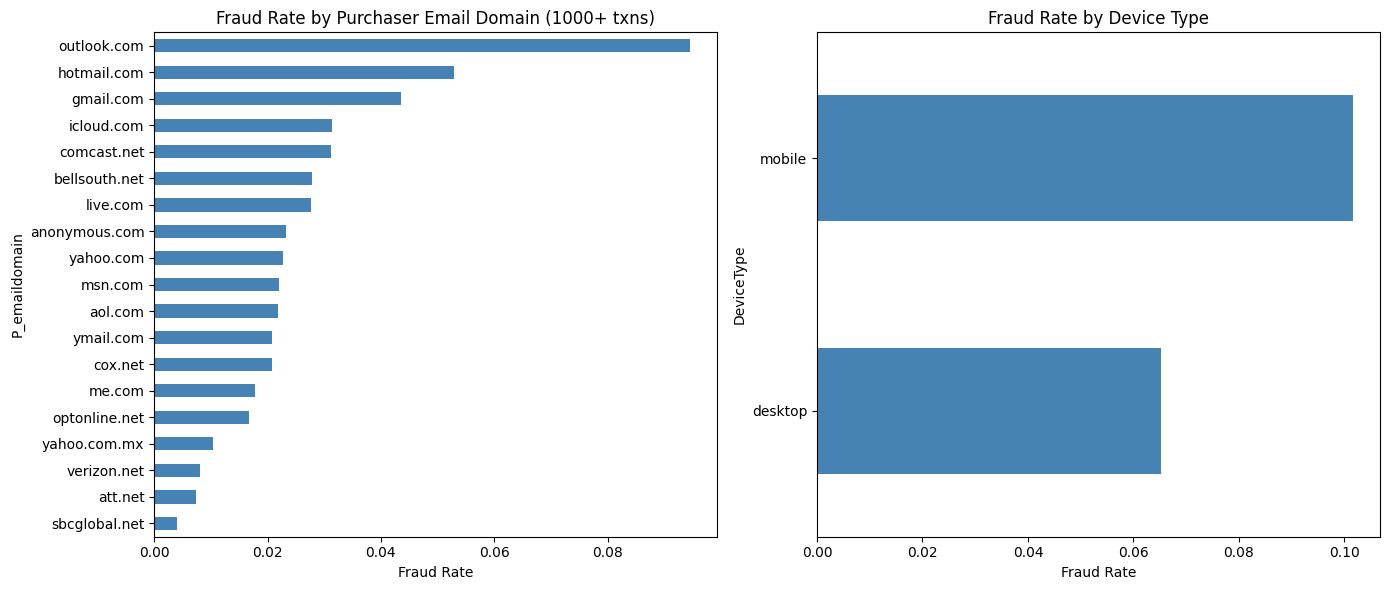

In [11]:
# Email domain analysis
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Top purchaser email domains by fraud rate (only domains with 1000+ transactions)
email_fraud = train.groupby('P_emaildomain').agg(
    fraud_rate=('isFraud', 'mean'),
    count=('isFraud', 'count')
)
email_fraud = email_fraud[email_fraud['count'] >= 1000].sort_values('fraud_rate', ascending=True)
email_fraud['fraud_rate'].plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Fraud Rate by Purchaser Email Domain (1000+ txns)')
axes[0].set_xlabel('Fraud Rate')

# Device type
train.groupby('DeviceType')['isFraud'].mean().sort_values().plot(
    kind='barh', ax=axes[1], color='steelblue')
axes[1].set_title('Fraud Rate by Device Type')
axes[1].set_xlabel('Fraud Rate')

plt.tight_layout()
plt.show()

In [12]:
# ============================================
# FEATURE ENGINEERING
# ============================================

# Start fresh with the merged dataframe
# train = train_txn.merge(train_id, on='TransactionID', how='left')
# (already done above)

# --- 1. TIME FEATURES ---
# Extract meaningful time components from TransactionDT
train['hour'] = (train['TransactionDT'] / 3600) % 24  # hour of day
train['day'] = (train['TransactionDT'] / 86400)  # day number (for time-based split later)
train['weekday'] = ((train['TransactionDT'] / 86400) % 7).astype(int)  # day of week

# Is it during sleeping hours? (our EDA showed fraud peaks at 3-9am)
train['is_night'] = ((train['hour'] >= 0) & (train['hour'] <= 9)).astype(int)

print("Time features created:")
print(f"  hour range: {train['hour'].min():.1f} - {train['hour'].max():.1f}")
print(f"  day range: {train['day'].min():.1f} - {train['day'].max():.1f}")
print(f"  Night transactions: {train['is_night'].mean()*100:.1f}%")

Time features created:
  hour range: 0.0 - 24.0
  day range: 1.0 - 183.0
  Night transactions: 26.2%


In [13]:
# --- 2. TRANSACTION AMOUNT FEATURES ---
# The raw amount is useful, but context matters more.
# "$500" means nothing alone. "$500 when this card usually spends $30" is suspicious.

# Log transform (reduces skewness, helps tree models split better)
train['TransactionAmt_log'] = np.log1p(train['TransactionAmt'])

# Decimal part of amount (fraudsters often use round numbers)
train['TransactionAmt_decimal'] = (train['TransactionAmt'] - train['TransactionAmt'].astype(int))

# Is it a round number? ($100.00 vs $97.43)
train['is_round_amount'] = (train['TransactionAmt_decimal'] == 0).astype(int)

print("Amount features:")
print(f"  Round number transactions: {train['is_round_amount'].mean()*100:.1f}%")
print(f"  Fraud rate for round amounts: {train[train['is_round_amount']==1]['isFraud'].mean()*100:.2f}%")
print(f"  Fraud rate for non-round amounts: {train[train['is_round_amount']==0]['isFraud'].mean()*100:.2f}%")

Amount features:
  Round number transactions: 51.6%
  Fraud rate for round amounts: 3.57%
  Fraud rate for non-round amounts: 3.43%


In [14]:
# --- 3. CARD-LEVEL AGGREGATION FEATURES ---
# This is the most important block. We're computing statistics
# about each card's behavior, then comparing each transaction to
# that card's "normal" behavior.

# card1 is the primary card identifier (most granular)
card1_stats = train.groupby('card1')['TransactionAmt'].agg([
    'mean', 'std', 'count'
]).rename(columns={
    'mean': 'card1_amt_mean',
    'std': 'card1_amt_std', 
    'count': 'card1_txn_count'
})

train = train.merge(card1_stats, on='card1', how='left')

# How does THIS transaction compare to this card's normal spending?
train['card1_amt_deviation'] = (
    (train['TransactionAmt'] - train['card1_amt_mean']) / 
    (train['card1_amt_std'] + 1e-6)  # add small number to avoid division by zero
)

print("Card-level features:")
print(f"  Average transactions per card: {train['card1_txn_count'].mean():.1f}")
print(f"  Median transactions per card: {train['card1_txn_count'].median():.0f}")
print(f"\n  Fraud rate when deviation > 2 std: {train[train['card1_amt_deviation'] > 2]['isFraud'].mean()*100:.2f}%")
print(f"  Fraud rate when deviation < 2 std: {train[train['card1_amt_deviation'] <= 2]['isFraud'].mean()*100:.2f}%")

Card-level features:
  Average transactions per card: 2528.8
  Median transactions per card: 919

  Fraud rate when deviation > 2 std: 5.07%
  Fraud rate when deviation < 2 std: 3.43%


In [15]:
# --- 4. BETTER CARD IDENTITY ---
# card1 alone is too coarse. Combine card features for a finer identity.
# A unique card is better identified by: card1 + card2 + card3 + card5

train['card_id'] = (
    train['card1'].astype(str) + '_' + 
    train['card2'].fillna(-1).astype(str) + '_' + 
    train['card3'].fillna(-1).astype(str) + '_' + 
    train['card5'].fillna(-1).astype(str)
)

print(f"Unique card1 values: {train['card1'].nunique()}")
print(f"Unique card_id values: {train['card_id'].nunique()}")

# Recompute stats with the better card identity
card_id_stats = train.groupby('card_id').agg(
    card_id_amt_mean=('TransactionAmt', 'mean'),
    card_id_amt_std=('TransactionAmt', 'std'),
    card_id_txn_count=('TransactionAmt', 'count')
)

train = train.merge(card_id_stats, on='card_id', how='left')

train['card_id_amt_deviation'] = (
    (train['TransactionAmt'] - train['card_id_amt_mean']) / 
    (train['card_id_amt_std'] + 1e-6)
)

print(f"\nWith better card identity:")
print(f"  Average transactions per card_id: {train['card_id_txn_count'].mean():.1f}")
print(f"  Median transactions per card_id: {train['card_id_txn_count'].median():.0f}")
print(f"\n  Fraud rate when deviation > 2 std: {train[train['card_id_amt_deviation'] > 2]['isFraud'].mean()*100:.2f}%")
print(f"  Fraud rate when deviation <= 2 std: {train[train['card_id_amt_deviation'] <= 2]['isFraud'].mean()*100:.2f}%")

Unique card1 values: 13553
Unique card_id values: 14845

With better card identity:
  Average transactions per card_id: 2273.5
  Median transactions per card_id: 838

  Fraud rate when deviation > 2 std: 5.13%
  Fraud rate when deviation <= 2 std: 3.43%


In [16]:
# --- 5. EMAIL DOMAIN FEATURES ---
# Based on our EDA findings

# Is the email from an ISP? (low fraud rate)
isp_domains = ['sbcglobal.net', 'att.net', 'verizon.net', 'cox.net', 
               'comcast.net', 'bellsouth.net', 'optonline.net', 'charter.net',
               'frontier.com', 'frontiernet.net', 'centurylink.net']

train['P_email_is_isp'] = train['P_emaildomain'].isin(isp_domains).astype(int)
train['R_email_is_isp'] = train['R_emaildomain'].isin(isp_domains).astype(int)

# Do purchaser and recipient have the same email domain?
train['email_domain_match'] = (
    train['P_emaildomain'] == train['R_emaildomain']
).astype(int)

# Is email missing?
train['P_email_missing'] = train['P_emaildomain'].isnull().astype(int)
train['R_email_missing'] = train['R_emaildomain'].isnull().astype(int)

print("Email features:")
print(f"  ISP email fraud rate: {train[train['P_email_is_isp']==1]['isFraud'].mean()*100:.2f}%")
print(f"  Non-ISP email fraud rate: {train[train['P_email_is_isp']==0]['isFraud'].mean()*100:.2f}%")
print(f"  Email domain match fraud rate: {train[train['email_domain_match']==1]['isFraud'].mean()*100:.2f}%")
print(f"  Email domain mismatch fraud rate: {train[train['email_domain_match']==0]['isFraud'].mean()*100:.2f}%")

Email features:
  ISP email fraud rate: 1.91%
  Non-ISP email fraud rate: 3.56%
  Email domain match fraud rate: 9.65%
  Email domain mismatch fraud rate: 2.21%


In [17]:
# --- 6. IDENTITY AND DEVICE FEATURES ---
train['has_identity'] = (~train['DeviceType'].isnull()).astype(int)

# Device type encoding
train['is_mobile'] = (train['DeviceType'] == 'mobile').astype(int)

# Browser - simplify to major browsers only
train['browser_clean'] = train['id_31'].fillna('unknown')
train['browser_clean'] = train['browser_clean'].apply(
    lambda x: 'chrome' if 'chrome' in str(x).lower()
    else 'safari' if 'safari' in str(x).lower()
    else 'firefox' if 'firefox' in str(x).lower()
    else 'edge' if 'edge' in str(x).lower()
    else 'ie' if 'ie' in str(x).lower() or 'explorer' in str(x).lower()
    else 'samsung' if 'samsung' in str(x).lower()
    else 'other'
)

print("Identity features:")
print(f"  Mobile fraud rate: {train[train['is_mobile']==1]['isFraud'].mean()*100:.2f}%")
print(f"  Desktop fraud rate: {train[train['is_mobile']==0]['isFraud'].mean()*100:.2f}%")
print(f"\nBrowser fraud rates:")
print(train.groupby('browser_clean')['isFraud'].agg(['mean', 'count']).sort_values('mean', ascending=False).to_string())

Identity features:
  Mobile fraud rate: 10.17%
  Desktop fraud rate: 2.81%

Browser fraud rates:
                   mean   count
browser_clean                  
chrome         0.095952   76059
samsung        0.087227    2247
firefox        0.078809    7017
safari         0.063947   37281
edge           0.035151    6401
ie             0.025454   10018
other          0.021598  451517


In [18]:
# --- 7. V-FEATURE BLOCK AGGREGATION ---
# Instead of using all 339 V features raw, aggregate each block.
# This reduces dimensionality and handles the missing pattern naturally.

v_blocks = {
    'v_block1': [f'V{i}' for i in range(1, 12)],       # 47% missing
    'v_block2': [f'V{i}' for i in range(12, 35)],      # 13% missing
    'v_block3': [f'V{i}' for i in range(35, 53)],      # 29% missing
    'v_block4': [f'V{i}' for i in range(53, 75)],      # 13% missing
    'v_block5': [f'V{i}' for i in range(75, 95)],      # 15% missing
    'v_block6': [f'V{i}' for i in range(95, 138)],     # ~0% missing
    'v_block7': [f'V{i}' for i in range(138, 167)],    # 86% missing
    'v_block8': [f'V{i}' for i in range(167, 217)],    # 76% missing
    'v_block9': [f'V{i}' for i in range(217, 279)],    # 77% missing
    'v_block10': [f'V{i}' for i in range(279, 322)],   # ~0% missing
    'v_block11': [f'V{i}' for i in range(322, 340)],   # 86% missing
}

for block_name, cols in v_blocks.items():
    existing_cols = [c for c in cols if c in train.columns]
    if existing_cols:
        train[f'{block_name}_mean'] = train[existing_cols].mean(axis=1)
        train[f'{block_name}_std'] = train[existing_cols].std(axis=1)
        train[f'{block_name}_null_count'] = train[existing_cols].isnull().sum(axis=1)

print(f"Created {len(v_blocks) * 3} V-block aggregate features")
print(f"\nTotal features now: {train.shape[1]}")

Created 33 V-block aggregate features

Total features now: 491


In [19]:
# --- 8. PREPARE FINAL FEATURE SET ---

# Features we engineered
engineered_features = [
    # Time features
    'hour', 'weekday', 'is_night',
    
    # Amount features
    'TransactionAmt', 'TransactionAmt_log', 'TransactionAmt_decimal', 'is_round_amount',
    
    # Card features
    'card1_amt_mean', 'card1_amt_std', 'card1_txn_count', 'card1_amt_deviation',
    
    # Email features
    'P_email_is_isp', 'R_email_is_isp', 'email_domain_match',
    'P_email_missing', 'R_email_missing',
    
    # Identity features
    'has_identity', 'is_mobile',
]

# Original useful features (numeric ones the model can use directly)
original_numeric = [
    'card1', 'card2', 'card3', 'card5',  # card identifiers
    'addr1', 'addr2',                     # address
    'dist1', 'dist2',                     # distance
    'C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9', 'C10', 'C11', 'C12', 'C13', 'C14',
    'D1', 'D2', 'D3', 'D4', 'D5', 'D6', 'D7', 'D8', 'D9', 'D10', 'D11', 'D15',
]

# V-block aggregates
v_block_features = [c for c in train.columns if c.startswith('v_block')]

# Combine all
feature_cols = engineered_features + original_numeric + v_block_features

# Verify all features exist
missing_feats = [f for f in feature_cols if f not in train.columns]
if missing_feats:
    print(f"WARNING - missing features: {missing_feats}")
    feature_cols = [f for f in feature_cols if f in train.columns]

print(f"Total features for modeling: {len(feature_cols)}")
print(f"\nBreakdown:")
print(f"  Engineered: {len(engineered_features)}")
print(f"  Original numeric: {len(original_numeric)}")
print(f"  V-block aggregates: {len(v_block_features)}")

Total features for modeling: 85

Breakdown:
  Engineered: 18
  Original numeric: 34
  V-block aggregates: 33


In [20]:
# --- 9. TIME-BASED TRAIN/VALIDATION SPLIT ---
# CRITICAL: Never use random split for fraud detection.
# In production, you always predict FUTURE transactions.
# So we train on earlier data and validate on later data.

split_day = 150  # First ~5 months for training, last month for validation

train_idx = train['day'] <= split_day
val_idx = train['day'] > split_day

X_train = train.loc[train_idx, feature_cols]
y_train = train.loc[train_idx, 'isFraud']
X_val = train.loc[val_idx, feature_cols]
y_val = train.loc[val_idx, 'isFraud']

print(f"Training set: {X_train.shape[0]} transactions ({y_train.mean()*100:.2f}% fraud)")
print(f"Validation set: {X_val.shape[0]} transactions ({y_val.mean()*100:.2f}% fraud)")
print(f"\nTraining period: day 1 to {split_day}")
print(f"Validation period: day {split_day} to 183")

Training set: 495905 transactions (3.50% fraud)
Validation set: 94635 transactions (3.47% fraud)

Training period: day 1 to 150
Validation period: day 150 to 183


In [21]:
import lightgbm as lgb
from sklearn.metrics import (
    roc_auc_score, average_precision_score, 
    classification_report, confusion_matrix,
    precision_recall_curve
)

# --- 10. BASELINE LIGHTGBM MODEL ---
# Start simple. No fancy tuning. Just see where we stand.

model = lgb.LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    num_leaves=31,
    min_child_samples=50,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=len(y_train[y_train==0]) / len(y_train[y_train==1]),  # handle imbalance
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[lgb.early_stopping(50), lgb.log_evaluation(100)]
)

print(f"\nBest iteration: {model.best_iteration_}")

Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[1]	valid_0's binary_logloss: 0.141611

Best iteration: 1


In [22]:
# --- 10b. FIXED BASELINE ---
# Reduce scale_pos_weight and let the model learn more gradually

model = lgb.LGBMClassifier(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=6,
    num_leaves=31,
    min_child_samples=50,
    subsample=0.8,
    colsample_bytree=0.8,
    is_unbalance=True,  # let LightGBM handle imbalance internally (gentler than manual weight)
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[lgb.early_stopping(50), lgb.log_evaluation(100)]
)

print(f"\nBest iteration: {model.best_iteration_}")

Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[1]	valid_0's binary_logloss: 0.141611

Best iteration: 1


In [23]:
# Let's check what the data actually looks like
print("X_train dtypes value counts:")
print(X_train.dtypes.value_counts())
print(f"\nNaN counts in X_train: {X_train.isnull().sum().sum()}")
print(f"Inf counts: {np.isinf(X_train.select_dtypes(include=np.number)).sum().sum()}")
print(f"\nX_train shape: {X_train.shape}")
print(f"y_train distribution:\n{y_train.value_counts()}")

# Check a few rows
print(f"\nFirst 3 rows sample:")
print(X_train.head(3).to_string())

X_train dtypes value counts:
float64    62
int64      23
Name: count, dtype: int64

NaN counts in X_train: 8362382
Inf counts: 0

X_train shape: (495905, 85)
y_train distribution:
isFraud
0    478524
1     17381
Name: count, dtype: int64

First 3 rows sample:
       hour  weekday  is_night  TransactionAmt  TransactionAmt_log  TransactionAmt_decimal  is_round_amount  card1_amt_mean  card1_amt_std  card1_txn_count  card1_amt_deviation  P_email_is_isp  R_email_is_isp  email_domain_match  P_email_missing  R_email_missing  has_identity  is_mobile  card1  card2  card3  card5  addr1  addr2  dist1  dist2   C1   C2   C3   C4   C5   C6   C7   C8   C9  C10  C11  C12  C13  C14    D1  D2    D3   D4  D5  D6  D7  D8  D9   D10    D11    D15  v_block1_mean  v_block1_std  v_block1_null_count  v_block2_mean  v_block2_std  v_block2_null_count  v_block3_mean  v_block3_std  v_block3_null_count  v_block4_mean  v_block4_std  v_block4_null_count  v_block5_mean  v_block5_std  v_block5_null_count  v_block6_mean 

In [24]:
# Check for extreme values
print("card1_amt_deviation stats:")
print(X_train['card1_amt_deviation'].describe())
print(f"\nValues > 1000: {(X_train['card1_amt_deviation'].abs() > 1000).sum()}")
print(f"Values > 100: {(X_train['card1_amt_deviation'].abs() > 100).sum()}")

# Same for card_id version if it exists
if 'card_id_amt_deviation' in X_train.columns:
    print(f"\ncard_id_amt_deviation max: {X_train['card_id_amt_deviation'].max()}")

card1_amt_deviation stats:
count    492953.000000
mean          0.000186
std           0.988582
min          -4.125851
25%          -0.463179
50%          -0.286611
75%           0.101672
max          36.905841
Name: card1_amt_deviation, dtype: float64

Values > 1000: 0
Values > 100: 0


In [25]:
# Fix: clip extreme deviations and try training without is_unbalance first
# to see if the model can learn at all

X_train['card1_amt_deviation'] = X_train['card1_amt_deviation'].clip(-10, 10)
X_val['card1_amt_deviation'] = X_val['card1_amt_deviation'].clip(-10, 10)

# Try a simple model first — no imbalance handling, just pure LightGBM
model = lgb.LGBMClassifier(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=6,
    num_leaves=31,
    min_child_samples=50,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[lgb.early_stopping(50), lgb.log_evaluation(100)]
)

print(f"\nBest iteration: {model.best_iteration_}")

Training until validation scores don't improve for 50 rounds
[100]	valid_0's binary_logloss: 0.0949362
[200]	valid_0's binary_logloss: 0.091708
[300]	valid_0's binary_logloss: 0.089788
[400]	valid_0's binary_logloss: 0.0882869
[500]	valid_0's binary_logloss: 0.0874594
[600]	valid_0's binary_logloss: 0.0868141
[700]	valid_0's binary_logloss: 0.0860982
[800]	valid_0's binary_logloss: 0.0854726
[900]	valid_0's binary_logloss: 0.0852224
[1000]	valid_0's binary_logloss: 0.0847662
Did not meet early stopping. Best iteration is:
[1000]	valid_0's binary_logloss: 0.0847662

Best iteration: 1000


In [26]:
# --- 11. EXTENDED TRAINING ---
# The model wants more trees. Let's give it 2000 and let early stopping decide.

model = lgb.LGBMClassifier(
    n_estimators=2000,
    learning_rate=0.05,
    max_depth=6,
    num_leaves=31,
    min_child_samples=50,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[lgb.early_stopping(50), lgb.log_evaluation(200)]
)

print(f"\nBest iteration: {model.best_iteration_}")

Training until validation scores don't improve for 50 rounds
[200]	valid_0's binary_logloss: 0.091708
[400]	valid_0's binary_logloss: 0.0882869
[600]	valid_0's binary_logloss: 0.0868141
[800]	valid_0's binary_logloss: 0.0854726
[1000]	valid_0's binary_logloss: 0.0847662
[1200]	valid_0's binary_logloss: 0.0844303
[1400]	valid_0's binary_logloss: 0.0843019
Early stopping, best iteration is:
[1470]	valid_0's binary_logloss: 0.0842322

Best iteration: 1470


In [27]:
# --- 12. EVALUATE THE MODEL ---
# This is where we see how good (or bad) our model actually is.

y_pred_proba = model.predict_proba(X_val)[:, 1]  # probability of fraud
y_pred = (y_pred_proba >= 0.5).astype(int)        # default threshold

# Metrics
roc_auc = roc_auc_score(y_val, y_pred_proba)
pr_auc = average_precision_score(y_val, y_pred_proba)

print(f"ROC-AUC: {roc_auc:.4f}")
print(f"PR-AUC (Average Precision): {pr_auc:.4f}")
print(f"\nClassification Report (threshold=0.5):")
print(classification_report(y_val, y_pred, target_names=['Not Fraud', 'Fraud']))

# Confusion matrix
cm = confusion_matrix(y_val, y_pred)
print(f"Confusion Matrix:")
print(f"  True Negatives:  {cm[0][0]}  (legitimate correctly identified)")
print(f"  False Positives: {cm[0][1]}  (legitimate flagged as fraud)")
print(f"  False Negatives: {cm[1][0]}  (fraud missed)")
print(f"  True Positives:  {cm[1][1]}  (fraud caught)")
print(f"\n  Fraud catch rate: {cm[1][1]/(cm[1][0]+cm[1][1])*100:.1f}%")
print(f"  False alarm rate: {cm[0][1]/(cm[0][0]+cm[0][1])*100:.2f}%")

ROC-AUC: 0.9209
PR-AUC (Average Precision): 0.5836

Classification Report (threshold=0.5):
              precision    recall  f1-score   support

   Not Fraud       0.98      1.00      0.99     91353
       Fraud       0.83      0.39      0.53      3282

    accuracy                           0.98     94635
   macro avg       0.91      0.69      0.76     94635
weighted avg       0.97      0.98      0.97     94635

Confusion Matrix:
  True Negatives:  91097  (legitimate correctly identified)
  False Positives: 256  (legitimate flagged as fraud)
  False Negatives: 2006  (fraud missed)
  True Positives:  1276  (fraud caught)

  Fraud catch rate: 38.9%
  False alarm rate: 0.28%


From this result, we can infer that the model is trying to play safe and is only flagging the obvious ones. Now we'll try to include imbalance handling for better results.

In [28]:
# --- 13. THRESHOLD OPTIMIZATION ---
# Instead of the default 0.5, find the threshold that minimizes business cost.
# 
# Think about it from a business perspective:
# - Missing a fraud (False Negative) costs ~$500 (average fraud amount)
# - Blocking a legitimate transaction (False Positive) costs ~$10 (customer friction)
# So missing fraud is 50x worse than a false alarm.

from sklearn.metrics import precision_recall_curve

precisions, recalls, thresholds = precision_recall_curve(y_val, y_pred_proba)

# Calculate F1 at each threshold
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)
best_f1_idx = np.argmax(f1_scores)
best_threshold_f1 = thresholds[best_f1_idx]

# Also find threshold that catches at least 70% of fraud
recall_70_idx = np.where(recalls >= 0.70)[0][-1]
threshold_70_recall = thresholds[recall_70_idx]

print(f"Best F1 threshold: {best_threshold_f1:.4f} (F1={f1_scores[best_f1_idx]:.4f})")
print(f"70% recall threshold: {threshold_70_recall:.4f}")

# Evaluate at the better threshold
for name, thresh in [('Default (0.5)', 0.5), ('Best F1', best_threshold_f1), ('70% Recall', threshold_70_recall)]:
    y_pred_t = (y_pred_proba >= thresh).astype(int)
    cm = confusion_matrix(y_val, y_pred_t)
    precision = cm[1][1] / (cm[1][1] + cm[0][1]) if (cm[1][1] + cm[0][1]) > 0 else 0
    recall = cm[1][1] / (cm[1][1] + cm[1][0])
    
    print(f"\n--- {name} (threshold={thresh:.4f}) ---")
    print(f"  Fraud caught: {cm[1][1]}/{cm[1][0]+cm[1][1]} ({recall*100:.1f}%)")
    print(f"  False alarms: {cm[0][1]} ({cm[0][1]/(cm[0][0]+cm[0][1])*100:.2f}%)")
    print(f"  Precision: {precision*100:.1f}%")

Best F1 threshold: 0.2398 (F1=0.5749)
70% recall threshold: 0.0602

--- Default (0.5) (threshold=0.5000) ---
  Fraud caught: 1276/3282 (38.9%)
  False alarms: 256 (0.28%)
  Precision: 83.3%

--- Best F1 (threshold=0.2398) ---
  Fraud caught: 1655/3282 (50.4%)
  False alarms: 821 (0.90%)
  Precision: 66.8%

--- 70% Recall (threshold=0.0602) ---
  Fraud caught: 2298/3282 (70.0%)
  False alarms: 4937 (5.40%)
  Precision: 31.8%


The above shows the tradeoff very clearly; if we want more fraud caught, more unhappy customers will be around. So in this situation, there is no correct answer. So now we will be see which features are doing the main tasks/

In [29]:
# --- 14. FEATURE IMPORTANCE ---
# Before adding more features, let's see what the model actually found useful.
# This tells us which of our 85 features are doing the heavy lifting.

importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

print("Top 20 most important features:")
print(importance.head(20).to_string(index=False))

print(f"\nFeatures with zero importance (useless): {(importance['importance']==0).sum()}")

Top 20 most important features:
               feature  importance
                 card1        1951
       card1_txn_count        1936
                 card2        1919
                 addr1        1905
         card1_amt_std        1764
        card1_amt_mean        1683
        TransactionAmt        1458
                  hour        1302
   card1_amt_deviation        1300
                   D15        1178
                    D2        1133
                   C13        1067
                 dist1         968
                    D8         906
                    C1         892
                    D4         809
TransactionAmt_decimal         806
                    D1         796
          v_block4_std         794
                   D10         783

Features with zero importance (useless): 6


In [30]:
# --- 15. MORE FEATURES ---
# Based on what we've learned, let's add features we missed.

# Interaction: amount relative to card's address region
addr1_stats = train.groupby('addr1')['TransactionAmt'].agg(['mean', 'std']).rename(
    columns={'mean': 'addr1_amt_mean', 'std': 'addr1_amt_std'})
train = train.merge(addr1_stats, on='addr1', how='left')

# Transaction frequency: how many transactions does this card have per day?
train['card1_txn_per_day'] = train['card1_txn_count'] / 183  # total days in dataset

# Interaction features: combine strong individual signals
train['amt_x_is_night'] = train['TransactionAmt_log'] * train['is_night']
train['amt_x_is_mobile'] = train['TransactionAmt_log'] * train['is_mobile']

# C-feature ratios (counting features relative to each other)
train['C1_C2_ratio'] = train['C1'] / (train['C2'] + 1e-6)
train['C13_C14_ratio'] = train['C13'] / (train['C14'] + 1e-6)

# D1 missing flag (D1 = days since first transaction with this card)
train['D1_missing'] = train['D1'].isnull().astype(int)

# How many M-features (match flags) are "T" (true)?
m_cols = [f'M{i}' for i in range(1, 10) if f'M{i}' in train.columns]
for col in m_cols:
    train[f'{col}_is_T'] = (train[col] == 'T').astype(int)
train['M_true_count'] = sum(train[f'{col}_is_T'] for col in m_cols)

# Update feature list
new_features = [
    'addr1_amt_mean', 'addr1_amt_std',
    'card1_txn_per_day',
    'amt_x_is_night', 'amt_x_is_mobile',
    'C1_C2_ratio', 'C13_C14_ratio',
    'D1_missing', 'M_true_count'
]

feature_cols_v2 = feature_cols + [f for f in new_features if f in train.columns]

# Rebuild train/val with new features
X_train_v2 = train.loc[train_idx, feature_cols_v2]
X_val_v2 = train.loc[val_idx, feature_cols_v2]

# Clip deviations again
X_train_v2['card1_amt_deviation'] = X_train_v2['card1_amt_deviation'].clip(-10, 10)
X_val_v2['card1_amt_deviation'] = X_val_v2['card1_amt_deviation'].clip(-10, 10)

print(f"Features v1: {len(feature_cols)}")
print(f"Features v2: {len(feature_cols_v2)}")

Features v1: 85
Features v2: 94


In [31]:
# --- 16. RETRAIN WITH MORE FEATURES ---
model_v2 = lgb.LGBMClassifier(
    n_estimators=2000,
    learning_rate=0.03,        # slightly lower for more careful learning
    max_depth=7,               # slightly deeper to capture interactions
    num_leaves=40,
    min_child_samples=50,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,             # L1 regularization to prevent overfitting
    reg_lambda=1.0,            # L2 regularization
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

model_v2.fit(
    X_train_v2, y_train,
    eval_set=[(X_val_v2, y_val)],
    callbacks=[lgb.early_stopping(50), lgb.log_evaluation(200)]
)

# Evaluate
y_pred_proba_v2 = model_v2.predict_proba(X_val_v2)[:, 1]

roc_auc_v2 = roc_auc_score(y_val, y_pred_proba_v2)
pr_auc_v2 = average_precision_score(y_val, y_pred_proba_v2)

print(f"\n--- Model v1 vs v2 ---")
print(f"ROC-AUC:  {roc_auc:.4f} → {roc_auc_v2:.4f}")
print(f"PR-AUC:   {pr_auc:.4f} → {pr_auc_v2:.4f}")

Training until validation scores don't improve for 50 rounds
[200]	valid_0's binary_logloss: 0.0919813
[400]	valid_0's binary_logloss: 0.0887755
[600]	valid_0's binary_logloss: 0.0868636
[800]	valid_0's binary_logloss: 0.0857352
[1000]	valid_0's binary_logloss: 0.0851152
[1200]	valid_0's binary_logloss: 0.0842271
[1400]	valid_0's binary_logloss: 0.0838015
Early stopping, best iteration is:
[1472]	valid_0's binary_logloss: 0.0836591

--- Model v1 vs v2 ---
ROC-AUC:  0.9209 → 0.9217
PR-AUC:   0.5836 → 0.5844


In [32]:
# --- 17. V3: ADD RAW V-FEATURES + CATEGORICAL ENCODING ---
# We were too aggressive in reducing V features. 
# Let's keep the most useful raw V columns alongside our aggregates.

# Find which V columns have low missing rates (< 20%) — these are reliable
v_cols = [c for c in train.columns if c.startswith('V') and not c.startswith('v_block')]
v_missing_pct = train[v_cols].isnull().mean()
v_cols_low_missing = v_missing_pct[v_missing_pct < 0.20].index.tolist()

print(f"V columns with <20% missing: {len(v_cols_low_missing)}")

# Categorical features — label encode them
# LightGBM can handle categoricals natively, but they need to be integers
from sklearn.preprocessing import LabelEncoder

cat_cols = ['ProductCD', 'card4', 'card6', 'P_emaildomain', 'R_emaildomain', 
            'DeviceType', 'browser_clean']

label_encoders = {}
for col in cat_cols:
    if col in train.columns:
        le = LabelEncoder()
        # Handle NaN: fill with 'missing' before encoding
        train[f'{col}_encoded'] = train[col].fillna('missing').astype(str)
        le.fit(train[f'{col}_encoded'])
        train[f'{col}_encoded'] = le.transform(train[f'{col}_encoded'])
        label_encoders[col] = le

encoded_cat_cols = [f'{col}_encoded' for col in cat_cols if f'{col}_encoded' in train.columns]
print(f"Encoded categorical columns: {len(encoded_cat_cols)}")

# Build v3 feature set
feature_cols_v3 = feature_cols_v2 + v_cols_low_missing + encoded_cat_cols
# Remove duplicates
feature_cols_v3 = list(dict.fromkeys(feature_cols_v3))

X_train_v3 = train.loc[train_idx, feature_cols_v3]
X_val_v3 = train.loc[val_idx, feature_cols_v3]

print(f"\nFeatures v2: {len(feature_cols_v2)}")
print(f"Features v3: {len(feature_cols_v3)}")

V columns with <20% missing: 151
Encoded categorical columns: 7

Features v2: 94
Features v3: 252


In [33]:
# --- 18. TRAIN V3 ---
model_v3 = lgb.LGBMClassifier(
    n_estimators=2000,
    learning_rate=0.03,
    max_depth=7,
    num_leaves=50,
    min_child_samples=50,
    subsample=0.8,
    colsample_bytree=0.6,  # lower — forces model to explore different feature combos
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

model_v3.fit(
    X_train_v3, y_train,
    eval_set=[(X_val_v3, y_val)],
    callbacks=[lgb.early_stopping(50), lgb.log_evaluation(200)]
)

y_pred_proba_v3 = model_v3.predict_proba(X_val_v3)[:, 1]

roc_auc_v3 = roc_auc_score(y_val, y_pred_proba_v3)
pr_auc_v3 = average_precision_score(y_val, y_pred_proba_v3)

print(f"\n--- Model Progression ---")
print(f"v1 → ROC-AUC: {roc_auc:.4f}  |  PR-AUC: {pr_auc:.4f}  |  85 features")
print(f"v2 → ROC-AUC: {roc_auc_v2:.4f}  |  PR-AUC: {pr_auc_v2:.4f}  |  {len(feature_cols_v2)} features")
print(f"v3 → ROC-AUC: {roc_auc_v3:.4f}  |  PR-AUC: {pr_auc_v3:.4f}  |  {len(feature_cols_v3)} features")

Training until validation scores don't improve for 50 rounds
[200]	valid_0's binary_logloss: 0.0907303
[400]	valid_0's binary_logloss: 0.0874084
[600]	valid_0's binary_logloss: 0.0855632
[800]	valid_0's binary_logloss: 0.0843071
[1000]	valid_0's binary_logloss: 0.0834626
[1200]	valid_0's binary_logloss: 0.082807
[1400]	valid_0's binary_logloss: 0.0823259
Early stopping, best iteration is:
[1481]	valid_0's binary_logloss: 0.0822399

--- Model Progression ---
v1 → ROC-AUC: 0.9209  |  PR-AUC: 0.5836  |  85 features
v2 → ROC-AUC: 0.9217  |  PR-AUC: 0.5844  |  94 features
v3 → ROC-AUC: 0.9267  |  PR-AUC: 0.5956  |  252 features


In [34]:
# --- 19. V4: ALL V FEATURES + ALL D FEATURES ---
# Stop being conservative. Give the model everything and let it sort out what matters.

# All V columns
all_v_cols = [c for c in train.columns if c.startswith('V') and not c.startswith('v_block')]

# All D columns  
all_d_cols = [f'D{i}' for i in range(1, 16) if f'D{i}' in train.columns]

# All M columns encoded
m_encoded_cols = [c for c in train.columns if c.endswith('_is_T')]

# Start from our engineered features + categoricals, add everything raw
feature_cols_v4 = (
    engineered_features + 
    original_numeric + 
    v_block_features +     # our aggregates
    new_features +         # v2 features
    encoded_cat_cols +     # categoricals
    all_v_cols +           # ALL raw V features
    m_encoded_cols +       # M flag features
    ['M_true_count']
)

# Remove duplicates and non-existent columns
feature_cols_v4 = list(dict.fromkeys(feature_cols_v4))
feature_cols_v4 = [f for f in feature_cols_v4 if f in train.columns]

X_train_v4 = train.loc[train_idx, feature_cols_v4]
X_val_v4 = train.loc[val_idx, feature_cols_v4]

print(f"Features v4: {len(feature_cols_v4)}")

Features v4: 449


In [35]:
# --- 20. TRAIN V4 WITH TUNED PARAMETERS ---
model_v4 = lgb.LGBMClassifier(
    n_estimators=3000,
    learning_rate=0.02,       # slower learning for more features
    max_depth=8,
    num_leaves=60,
    min_child_samples=100,    # higher to prevent overfitting with 400+ features
    subsample=0.7,
    colsample_bytree=0.4,    # much lower — with 400+ features, each tree sees ~160
    reg_alpha=0.3,
    reg_lambda=2.0,           # stronger regularization
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

model_v4.fit(
    X_train_v4, y_train,
    eval_set=[(X_val_v4, y_val)],
    callbacks=[lgb.early_stopping(100), lgb.log_evaluation(200)]
)

y_pred_proba_v4 = model_v4.predict_proba(X_val_v4)[:, 1]

roc_auc_v4 = roc_auc_score(y_val, y_pred_proba_v4)
pr_auc_v4 = average_precision_score(y_val, y_pred_proba_v4)

print(f"\n--- Full Model Progression ---")
print(f"v1 → ROC-AUC: {roc_auc:.4f}  |  PR-AUC: {pr_auc:.4f}  |  85 features")
print(f"v2 → ROC-AUC: {roc_auc_v2:.4f}  |  PR-AUC: {pr_auc_v2:.4f}  |  {len(feature_cols_v2)} features")
print(f"v3 → ROC-AUC: {roc_auc_v3:.4f}  |  PR-AUC: {pr_auc_v3:.4f}  |  {len(feature_cols_v3)} features")
print(f"v4 → ROC-AUC: {roc_auc_v4:.4f}  |  PR-AUC: {pr_auc_v4:.4f}  |  {len(feature_cols_v4)} features")

Training until validation scores don't improve for 100 rounds
[200]	valid_0's binary_logloss: 0.0922732
[400]	valid_0's binary_logloss: 0.0885081
[600]	valid_0's binary_logloss: 0.0867562
[800]	valid_0's binary_logloss: 0.0854251
[1000]	valid_0's binary_logloss: 0.0844401
[1200]	valid_0's binary_logloss: 0.0838142
[1400]	valid_0's binary_logloss: 0.0833569
[1600]	valid_0's binary_logloss: 0.0830691
[1800]	valid_0's binary_logloss: 0.0827304
[2000]	valid_0's binary_logloss: 0.0824845
[2200]	valid_0's binary_logloss: 0.0823655
[2400]	valid_0's binary_logloss: 0.0822274
[2600]	valid_0's binary_logloss: 0.0822015
Early stopping, best iteration is:
[2622]	valid_0's binary_logloss: 0.0821799

--- Full Model Progression ---
v1 → ROC-AUC: 0.9209  |  PR-AUC: 0.5836  |  85 features
v2 → ROC-AUC: 0.9217  |  PR-AUC: 0.5844  |  94 features
v3 → ROC-AUC: 0.9267  |  PR-AUC: 0.5956  |  252 features
v4 → ROC-AUC: 0.9229  |  PR-AUC: 0.6096  |  449 features


In [36]:
# --- 21. V5: BEST OF BOTH WORLDS ---
# v3 had best ROC-AUC, v4 had best PR-AUC
# Keep v3's feature set + add M flags and categoricals that helped v4

# V features with < 50% missing (compromise between v3's 20% and v4's everything)
v_cols_medium = v_missing_pct[v_missing_pct < 0.50].index.tolist()
print(f"V columns with <50% missing: {len(v_cols_medium)}")

feature_cols_v5 = (
    engineered_features +
    original_numeric +
    v_block_features +
    new_features +
    encoded_cat_cols +
    v_cols_medium +
    m_encoded_cols +
    ['M_true_count']
)

feature_cols_v5 = list(dict.fromkeys(feature_cols_v5))
feature_cols_v5 = [f for f in feature_cols_v5 if f in train.columns]

X_train_v5 = train.loc[train_idx, feature_cols_v5]
X_val_v5 = train.loc[val_idx, feature_cols_v5]

print(f"Features v5: {len(feature_cols_v5)}")

# Train
model_v5 = lgb.LGBMClassifier(
    n_estimators=3000,
    learning_rate=0.02,
    max_depth=7,
    num_leaves=50,
    min_child_samples=80,
    subsample=0.75,
    colsample_bytree=0.5,
    reg_alpha=0.2,
    reg_lambda=1.5,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

model_v5.fit(
    X_train_v5, y_train,
    eval_set=[(X_val_v5, y_val)],
    callbacks=[lgb.early_stopping(100), lgb.log_evaluation(200)]
)

y_pred_proba_v5 = model_v5.predict_proba(X_val_v5)[:, 1]

roc_auc_v5 = roc_auc_score(y_val, y_pred_proba_v5)
pr_auc_v5 = average_precision_score(y_val, y_pred_proba_v5)

print(f"\n--- Full Model Progression ---")
print(f"v1 → ROC-AUC: {roc_auc:.4f}  |  PR-AUC: {pr_auc:.4f}  |  85 features")
print(f"v2 → ROC-AUC: {roc_auc_v2:.4f}  |  PR-AUC: {pr_auc_v2:.4f}  |  {len(feature_cols_v2)} features")
print(f"v3 → ROC-AUC: {roc_auc_v3:.4f}  |  PR-AUC: {pr_auc_v3:.4f}  |  {len(feature_cols_v3)} features")
print(f"v4 → ROC-AUC: {roc_auc_v4:.4f}  |  PR-AUC: {pr_auc_v4:.4f}  |  {len(feature_cols_v4)} features")
print(f"v5 → ROC-AUC: {roc_auc_v5:.4f}  |  PR-AUC: {pr_auc_v5:.4f}  |  {len(feature_cols_v5)} features")

V columns with <50% missing: 180
Features v5: 290
Training until validation scores don't improve for 100 rounds
[200]	valid_0's binary_logloss: 0.0938265
[400]	valid_0's binary_logloss: 0.0898642
[600]	valid_0's binary_logloss: 0.0879919
[800]	valid_0's binary_logloss: 0.0866614
[1000]	valid_0's binary_logloss: 0.085616
[1200]	valid_0's binary_logloss: 0.0847457
[1400]	valid_0's binary_logloss: 0.084005
[1600]	valid_0's binary_logloss: 0.0835217
[1800]	valid_0's binary_logloss: 0.0831301
[2000]	valid_0's binary_logloss: 0.082813
[2200]	valid_0's binary_logloss: 0.0825555
[2400]	valid_0's binary_logloss: 0.0823047
[2600]	valid_0's binary_logloss: 0.0821095
[2800]	valid_0's binary_logloss: 0.0819971
[3000]	valid_0's binary_logloss: 0.0819299
Did not meet early stopping. Best iteration is:
[2968]	valid_0's binary_logloss: 0.0819278

--- Full Model Progression ---
v1 → ROC-AUC: 0.9209  |  PR-AUC: 0.5836  |  85 features
v2 → ROC-AUC: 0.9217  |  PR-AUC: 0.5844  |  94 features
v3 → ROC-AUC: 0

In [37]:
# --- 22. SAVE THE BEST MODEL ---
import joblib

# Save model and feature list for later use in the API
joblib.dump(model_v5, 'model_v5.pkl')
joblib.dump(feature_cols_v5, 'feature_cols_v5.pkl')

print("Model saved!")
print(f"Model file size: {os.path.getsize('model_v5.pkl') / 1024:.0f} KB")

Model saved!
Model file size: 14470 KB


In [38]:
import os

X_val_v5.to_parquet('X_val_v5.parquet')
y_val.to_frame().to_parquet('y_val.parquet')
X_train_v5.to_parquet('X_train_v5.parquet')
y_train.to_frame().to_parquet('y_train.parquet')

print("All data saved!")
for f in ['X_val_v5.parquet', 'y_val.parquet', 'X_train_v5.parquet', 'y_train.parquet']:
    print(f"  {f}: {os.path.getsize(f)/1024/1024:.1f} MB")

All data saved!
  X_val_v5.parquet: 14.1 MB
  y_val.parquet: 0.6 MB
  X_train_v5.parquet: 67.9 MB
  y_train.parquet: 2.2 MB


In [39]:
import shap

explainer = shap.TreeExplainer(model_v5)
shap_values = explainer.shap_values(X_val_v5)

if isinstance(shap_values, list):
    shap_vals_fraud = shap_values[1]
else:
    shap_vals_fraud = shap_values

print(f"SHAP values shape: {shap_vals_fraud.shape}")
print("SHAP computation complete!")

SHAP values shape: (94635, 290)
SHAP computation complete!


/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:587: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


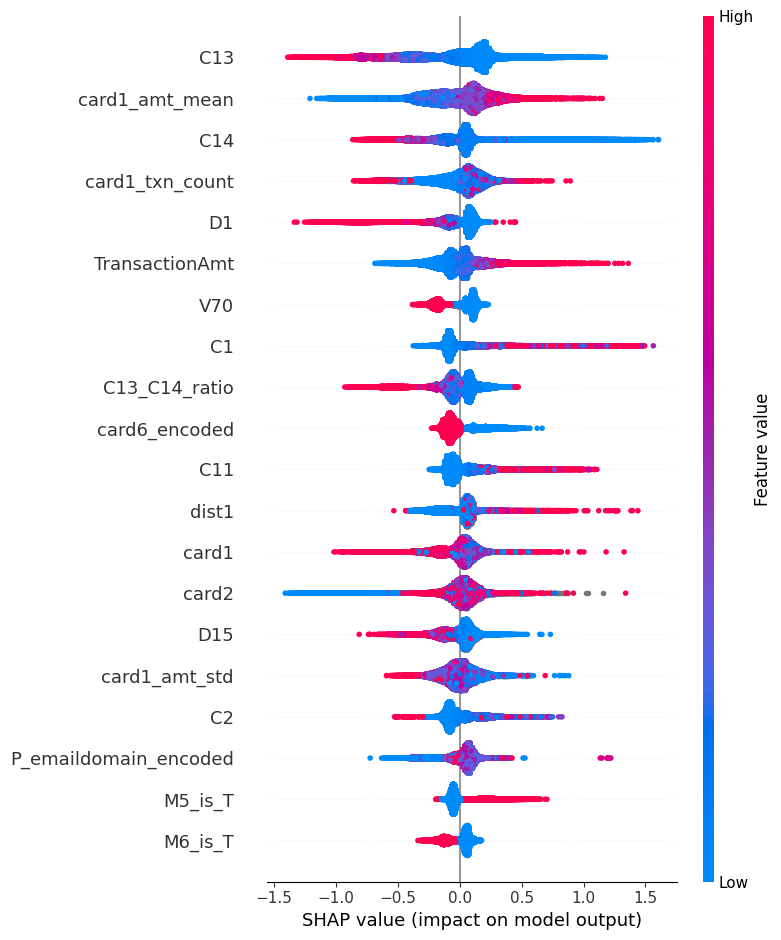

In [40]:
# Since full SHAP values computed, let's use them
# But sample for plotting (plotting 94K points is slow)

# --- 24. GLOBAL FEATURE IMPORTANCE ---
# Which features matter most ACROSS ALL transactions?

shap.summary_plot(shap_vals_fraud, X_val_v5, max_display=20, show=True)

Transaction index: 496689
Fraud probability: 0.9558
Actual label: 1 (1 = fraud)


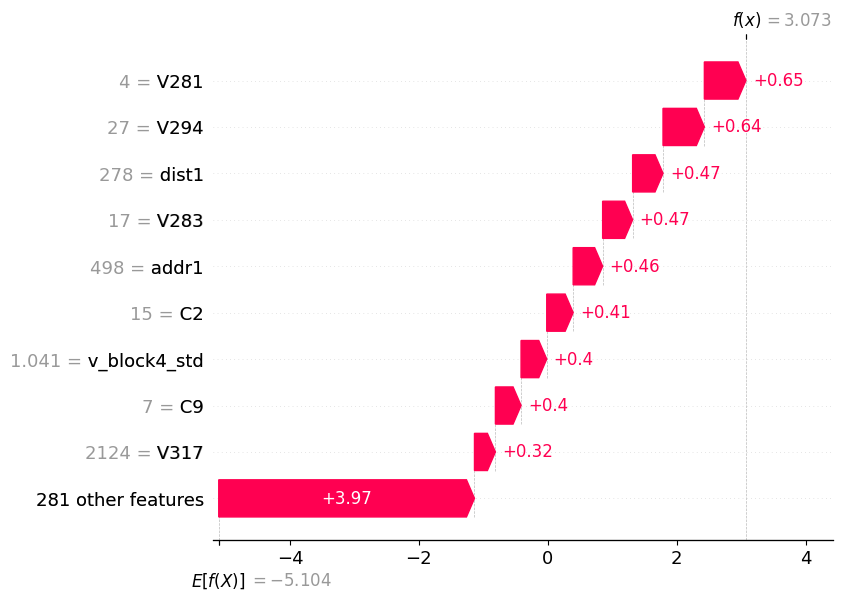

In [41]:
# --- 25. EXPLAIN A SPECIFIC FRAUD CASE ---
# Pick a transaction the model correctly flagged as fraud

y_pred_proba_v5 = model_v5.predict_proba(X_val_v5)[:, 1]

# Find a true positive with high confidence
fraud_mask = (y_val == 1) & (y_pred_proba_v5 > 0.8)
fraud_indices = y_val[fraud_mask].index.tolist()

if fraud_indices:
    idx = fraud_indices[0]
    # Get position in X_val_v5
    pos = X_val_v5.index.get_loc(idx)
    
    print(f"Transaction index: {idx}")
    print(f"Fraud probability: {y_pred_proba_v5[pos]:.4f}")
    print(f"Actual label: {y_val.iloc[pos]} (1 = fraud)")
    
    # Waterfall plot — shows exactly WHY this transaction was flagged
    shap.waterfall_plot(shap.Explanation(
        values=shap_vals_fraud[pos],
        base_values=explainer.expected_value[1] if isinstance(explainer.expected_value, list) else explainer.expected_value,
        data=X_val_v5.iloc[pos],
        feature_names=feature_cols_v5
    ))

False negatives with <10% fraud score: 1197

Transaction index: 496049
Fraud probability: 0.0011
Actual label: FRAUD (missed by model)


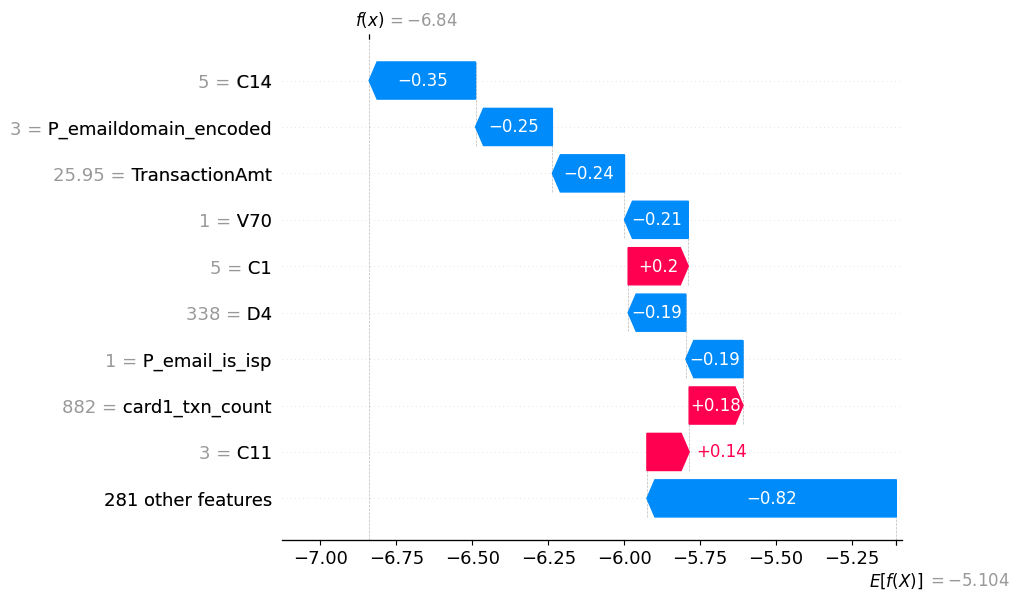

In [42]:
# --- 26. EXPLAIN A MISSED FRAUD (FALSE NEGATIVE) ---
# Find a fraud transaction the model gave low probability

false_neg_mask = (y_val == 1) & (y_pred_proba_v5 < 0.1)  # fraud but model said <10%
false_neg_indices = y_val[false_neg_mask].index.tolist()

print(f"False negatives with <10% fraud score: {len(false_neg_indices)}")

if false_neg_indices:
    idx = false_neg_indices[0]
    pos = X_val_v5.index.get_loc(idx)
    
    print(f"\nTransaction index: {idx}")
    print(f"Fraud probability: {y_pred_proba_v5[pos]:.4f}")
    print(f"Actual label: FRAUD (missed by model)")
    
    shap.waterfall_plot(shap.Explanation(
        values=shap_vals_fraud[pos],
        base_values=explainer.expected_value[1] if isinstance(explainer.expected_value, list) else explainer.expected_value,
        data=X_val_v5.iloc[pos],
        feature_names=feature_cols_v5
    ))

As we can see through this plot, the model struggles with a low amount of fraud using established cards and ISP emails. Future improvements could include sequence-based features tracking recent transaction patterns per card.

In [43]:
# --- 27. REUSABLE EXPLAIN FUNCTION ---
def explain_prediction(transaction_data, model, explainer, feature_names, shap_vals=None, pos=None):
    """
    Generate a human-readable explanation for a fraud prediction.
    This function will be used in the FastAPI endpoint later.
    """
    # Get prediction
    if hasattr(transaction_data, 'values'):
        pred_proba = model.predict_proba(transaction_data.values.reshape(1, -1))[0][1]
    else:
        pred_proba = model.predict_proba(transaction_data.reshape(1, -1))[0][1]
    
    # Get SHAP values
    if shap_vals is not None and pos is not None:
        sv = shap_vals[pos]
    else:
        sv_raw = explainer.shap_values(transaction_data.values.reshape(1, -1) if hasattr(transaction_data, 'values') else transaction_data.reshape(1, -1))
        if isinstance(sv_raw, list):
            sv = sv_raw[1][0]
        else:
            sv = sv_raw[0]
    
    # Get top contributing features
    feature_contributions = list(zip(feature_names, sv, transaction_data))
    feature_contributions.sort(key=lambda x: abs(x[1]), reverse=True)
    
    # Build explanation
    risk_level = "HIGH" if pred_proba > 0.7 else "MEDIUM" if pred_proba > 0.3 else "LOW"
    
    print(f"{'='*60}")
    print(f"FRAUD RISK ASSESSMENT")
    print(f"{'='*60}")
    print(f"Fraud Probability: {pred_proba*100:.2f}%")
    print(f"Risk Level: {risk_level}")
    print(f"\nTop factors:")
    
    for feat, shap_val, feat_val in feature_contributions[:8]:
        direction = "INCREASES" if shap_val > 0 else "DECREASES"
        print(f"  {feat} = {feat_val:.2f} → {direction} risk by {abs(shap_val):.3f}")
    
    return pred_proba, feature_contributions

# Test on our fraud case
print("--- TRUE FRAUD CASE ---")
idx = fraud_indices[0]
pos = X_val_v5.index.get_loc(idx)
_ = explain_prediction(X_val_v5.iloc[pos], model_v5, explainer, feature_cols_v5, shap_vals_fraud, pos)

print(f"\n--- MISSED FRAUD CASE ---")
idx2 = false_neg_indices[0]
pos2 = X_val_v5.index.get_loc(idx2)
_ = explain_prediction(X_val_v5.iloc[pos2], model_v5, explainer, feature_cols_v5, shap_vals_fraud, pos2)

--- TRUE FRAUD CASE ---
FRAUD RISK ASSESSMENT
Fraud Probability: 95.58%
Risk Level: HIGH

Top factors:
  V281 = 4.00 → INCREASES risk by 0.645
  V294 = 27.00 → INCREASES risk by 0.641
  dist1 = 278.00 → INCREASES risk by 0.471
  V283 = 17.00 → INCREASES risk by 0.465
  addr1 = 498.00 → INCREASES risk by 0.457
  C2 = 15.00 → INCREASES risk by 0.410
  v_block4_std = 1.04 → INCREASES risk by 0.398
  C9 = 7.00 → INCREASES risk by 0.398

--- MISSED FRAUD CASE ---
FRAUD RISK ASSESSMENT
Fraud Probability: 0.11%
Risk Level: LOW

Top factors:
  C14 = 5.00 → DECREASES risk by 0.350
  P_emaildomain_encoded = 3.00 → DECREASES risk by 0.253
  TransactionAmt = 25.95 → DECREASES risk by 0.237
  V70 = 1.00 → DECREASES risk by 0.210
  C1 = 5.00 → INCREASES risk by 0.198
  D4 = 338.00 → DECREASES risk by 0.190
  P_email_is_isp = 1.00 → DECREASES risk by 0.188
  card1_txn_count = 882.00 → INCREASES risk by 0.177


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [44]:
# --- 28. SAVE EVERYTHING FOR API DEPLOYMENT ---
import joblib
import json
import os

# Save model
joblib.dump(model_v5, 'model_v5.pkl')
joblib.dump(explainer, 'explainer.pkl')

# Save feature list
with open('feature_cols_v5.json', 'w') as f:
    json.dump(feature_cols_v5, f)

# Save validation data sample for testing the API later
X_val_v5.head(100).to_parquet('sample_transactions.parquet')

print("Saved files:")
for f in ['model_v5.pkl', 'explainer.pkl', 'feature_cols_v5.json', 'sample_transactions.parquet']:
    if os.path.exists(f):
        print(f"  {f}: {os.path.getsize(f)/1024/1024:.1f} MB")

Saved files:
  model_v5.pkl: 14.1 MB
  explainer.pkl: 38.6 MB
  feature_cols_v5.json: 0.0 MB
  sample_transactions.parquet: 0.2 MB
